# Comparative Analysis of Machine Learning and Deep Learning Models

## 1. Import Required Libraries

In [ ]:
# Install required packages
!pip install -q transformers accelerate wordcloud

In [ ]:
# Standard library imports
import os
import re
import string
import pickle
import joblib
import zipfile
import requests

# Numerical / data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

# NLP preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Scikit-learn – feature extraction & utilities
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, label_binarize

# Scikit-learn – ML models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier

# Scikit-learn – evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix,
)

# TensorFlow / Keras – deep learning
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout

# PyTorch + HuggingFace – BERT
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments

# Download NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Set global plot style
sns.set_style('whitegrid')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


## 2. Load Dataset

In [ ]:
# Fetch dataset metadata from Figshare API
api_url = "https://api.figshare.com/v2/articles/28390334"
metadata = requests.get(api_url).json()
files = metadata['files']

In [ ]:
# Download all dataset files into local 'dataset/' folder
os.makedirs('dataset', exist_ok=True)
downloaded_files = []
for f in files:
    file_path = os.path.join('dataset', f['name'])
    content = requests.get(f['download_url']).content
    with open(file_path, 'wb') as out_file:
        out_file.write(content)
    downloaded_files.append(file_path)

In [ ]:
# Extract any zip archives found in the downloads
for file_path in downloaded_files:
    if file_path.endswith('.zip'):
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall('dataset')

In [ ]:
# Helper to locate a file recursively inside a directory
def find_file(filename, root='dataset'):
    for dirpath, _, filenames in os.walk(root):
        if filename in filenames:
            return os.path.join(dirpath, filename)
    return None

In [ ]:
# Locate train and validation CSV paths
train_path = find_file('twitter_training.csv')
val_path   = find_file('twitter_validation.csv')

In [ ]:
# Load CSVs with explicit column names
columns = ['tweet_id', 'entity', 'sentiment', 'text']
train_df = pd.read_csv(train_path, header=None, names=columns)
val_df   = pd.read_csv(val_path,   header=None, names=columns)

In [ ]:
# Combine train + validation into one dataframe
df = pd.concat([train_df, val_df], ignore_index=True)
print(f"Combined dataset shape: {df.shape}")

Combined dataset shape: (75682, 4)


## 3. Dataset Overview

In [ ]:
# Shape of the combined dataset
print("Shape:", df.shape)

Shape: (75682, 4)


In [ ]:
# Column names
print("Columns:", df.columns.tolist())

Columns: ['tweet_id', 'entity', 'sentiment', 'text']


In [ ]:
# Data types per column
print(df.dtypes)

tweet_id      int64
entity       object
sentiment    object
text         object
dtype: object


In [ ]:
# Missing value counts per column
print(df.isnull().sum())

# Drop rows where tweet text is missing
df = df.dropna(subset=['text']).reset_index(drop=True)

tweet_id       0
entity         0
sentiment      0
text         686
dtype: int64


In [ ]:
# Count and remove duplicate rows
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

Duplicates: 2857


In [ ]:
# Summary statistics for all columns
df.describe(include='all')

,tweet_id,entity,sentiment,text
count,72139.000000,72139,72139,72139
unique,NaN,32,4,69974
top,NaN,TomClancysRainbowSix,Negative,"At the same time, despite the fact that there ..."
freq,NaN,2349,21790,172
mean,6435.469593,NaN,NaN,NaN
std,3743.598918,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN
25%,3195.000000,NaN,NaN,NaN
50%,6432.000000,NaN,NaN,NaN
75%,9607.000000,NaN,NaN,NaN


In [ ]:
# Value counts per sentiment class
df['sentiment'].value_counts()

,count
sentiment,
Negative,21790
Positive,19846
Neutral,17879
Irrelevant,12624


## 4. Exploratory Data Analysis

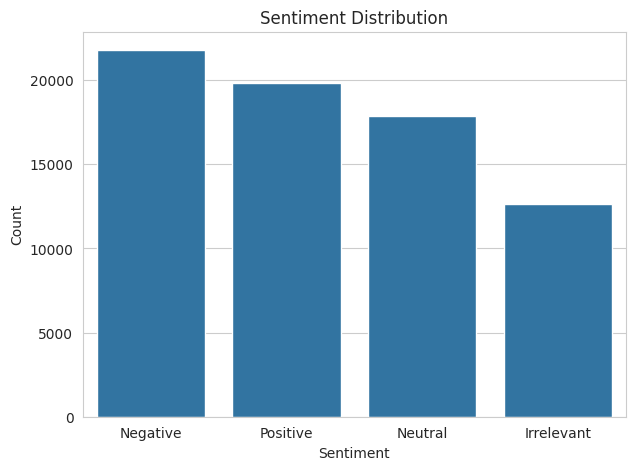

In [ ]:
# Bar chart – count of tweets per sentiment label
plt.figure(figsize=(7, 5))
sns.countplot(x='sentiment', data=df, order=df['sentiment'].value_counts().index)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

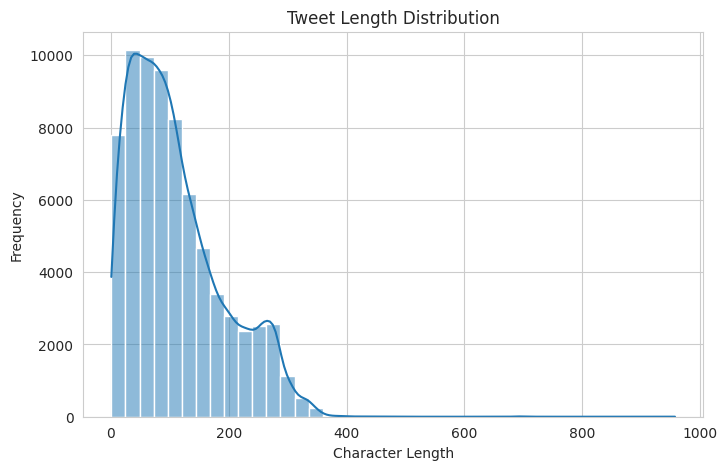

In [ ]:
# Histogram of tweet character lengths with KDE curve
tweet_length = df['text'].astype(str).apply(len)
plt.figure(figsize=(8, 5))
sns.histplot(tweet_length, bins=40, kde=True)
plt.title('Tweet Length Distribution')
plt.xlabel('Character Length')
plt.ylabel('Frequency')
plt.show()

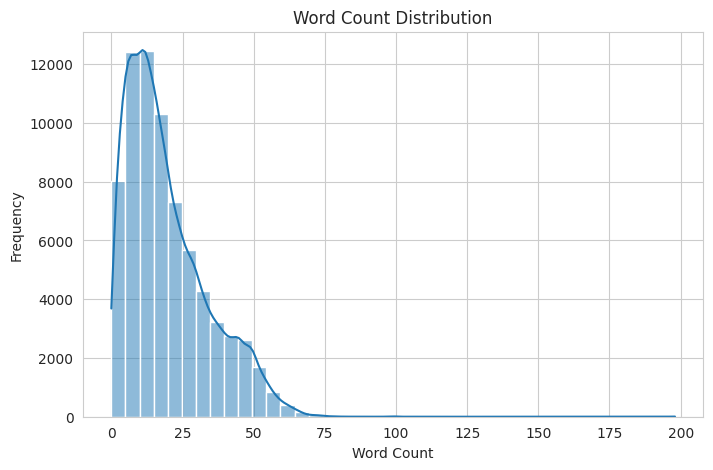

In [ ]:
# Histogram of word counts per tweet with KDE curve
word_count = df['text'].astype(str).apply(lambda x: len(x.split()))
plt.figure(figsize=(8, 5))
sns.histplot(word_count, bins=40, kde=True)
plt.title('Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

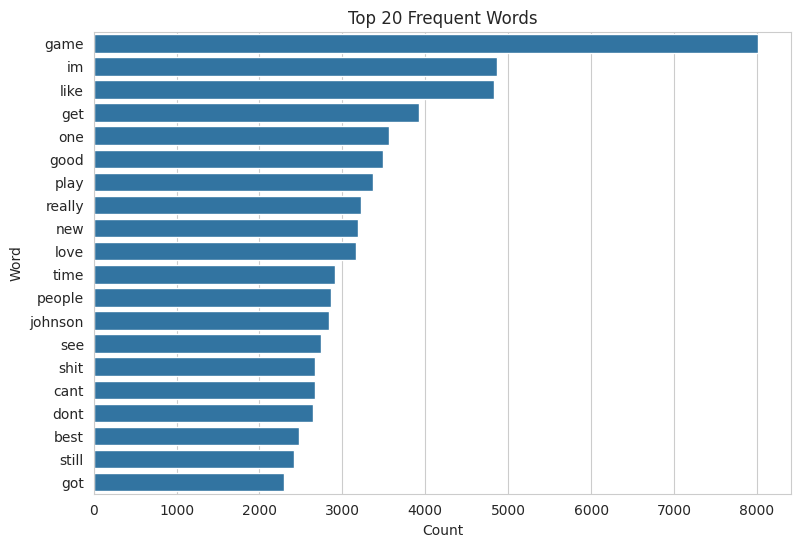

In [ ]:
# Tokenise and remove stop-words for EDA word frequency analysis
eda_stop_words = set(stopwords.words('english'))

def simple_tokens(text):
    """Lowercase, strip non-alpha chars, filter stop words."""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return [w for w in text.split() if w not in eda_stop_words and len(w) > 1]

# Flatten all tokens and count frequencies
all_words = df['text'].apply(simple_tokens).sum()
word_freq = Counter(all_words)
top_words = pd.DataFrame(word_freq.most_common(20), columns=['word', 'count'])

# Horizontal bar chart of the top 20 words
plt.figure(figsize=(9, 6))
sns.barplot(x='count', y='word', data=top_words)
plt.title('Top 20 Frequent Words')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

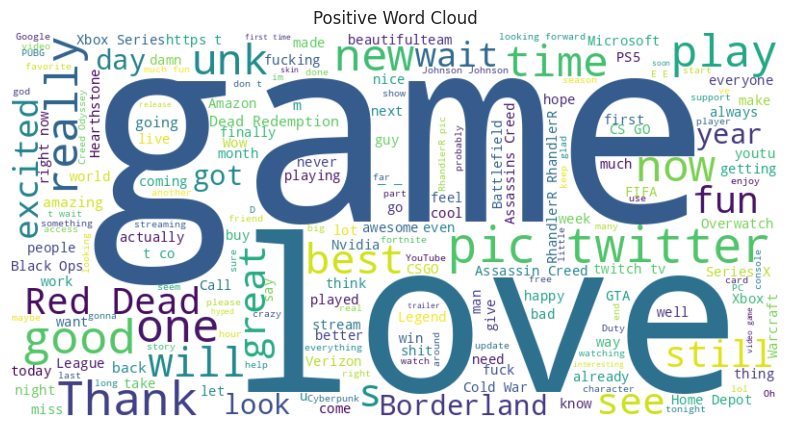

In [ ]:
# Word cloud generated from Positive sentiment tweets
positive_text  = ' '.join(df[df['sentiment'] == 'Positive']['text'].astype(str))
positive_cloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(positive_cloud, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Word Cloud')
plt.show()

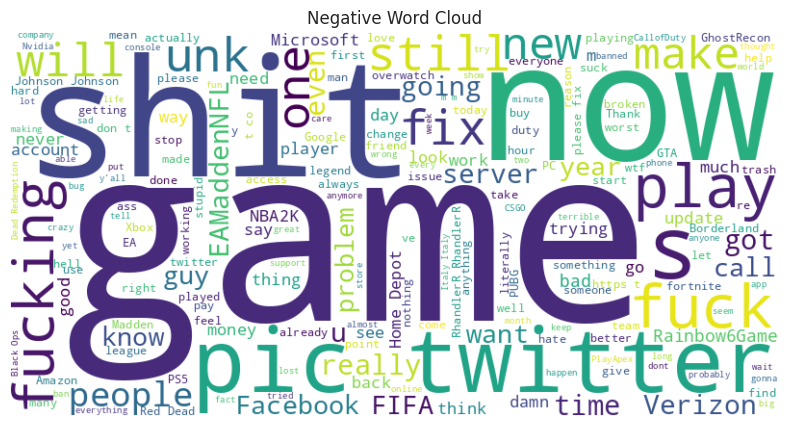

In [ ]:
# Word cloud generated from Negative sentiment tweets
negative_text  = ' '.join(df[df['sentiment'] == 'Negative']['text'].astype(str))
negative_cloud = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(negative_cloud, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Word Cloud')
plt.show()

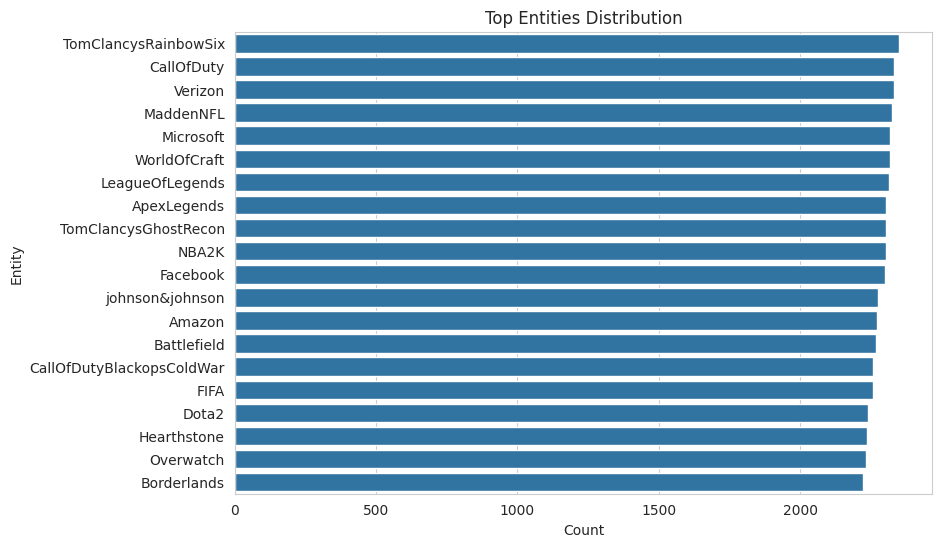

In [ ]:
# Bar chart of the 20 most frequent entity mentions in the dataset
top_entities = df['entity'].value_counts().head(20)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_entities.values, y=top_entities.index)
plt.title('Top Entities Distribution')
plt.xlabel('Count')
plt.ylabel('Entity')
plt.show()

## 5. Text Preprocessing

In [ ]:
# Step 1 – Lowercase all text
df['clean_text'] = df['text'].astype(str).str.lower()

In [ ]:
# Step 2 – Remove URLs (http / www links)
df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'http\S+|www\S+', '', x))

In [ ]:
# Step 3 – Strip HTML tags
df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'<.*?>', '', x))

In [ ]:
# Step 4 – Remove @mentions
df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'@\w+', '', x))

In [ ]:
# Step 5 – Remove #hashtags
df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'#\w+', '', x))

In [ ]:
# Step 6 – Remove emojis using Unicode ranges
def remove_emojis(text):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002700-\U000027BF"
        "\U0001F900-\U0001F9FF"
        "\U00002600-\U000026FF"
        "]+",
        flags=re.UNICODE,
    )
    return emoji_pattern.sub('', text)

df['clean_text'] = df['clean_text'].apply(remove_emojis)

In [ ]:
# Step 7 – Remove digits / numbers
df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'\d+', '', x))

In [ ]:
# Step 8 – Remove punctuation characters
df['clean_text'] = df['clean_text'].apply(
    lambda x: x.translate(str.maketrans('', '', string.punctuation))
)

In [ ]:
# Step 9 – Collapse extra whitespace and strip edges
df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

In [ ]:
# Step 10 – Tokenise cleaned text into word lists
df['tokens'] = df['clean_text'].apply(word_tokenize)

In [ ]:
# Step 11 – Remove English stop words from token lists
stop_words = set(stopwords.words('english'))
df['tokens'] = df['tokens'].apply(lambda x: [w for w in x if w not in stop_words])

In [ ]:
# Step 12 – Lemmatise tokens to their root form
lemmatizer = WordNetLemmatizer()
df['tokens']     = df['tokens'].apply(lambda x: [lemmatizer.lemmatize(w) for w in x])
df['final_text'] = df['tokens'].apply(lambda x: ' '.join(x))

# Remove rows where preprocessing left an empty string
df = df[df['final_text'].str.strip() != ''].reset_index(drop=True)
print(f"Rows after preprocessing: {len(df)}")

Rows after preprocessing: 70313


## 6. Feature Engineering

In [ ]:
# TF-IDF vectors (top 5000 features) for ML models
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(df['final_text'])

# Encode string sentiment labels to integers for all models
label_encoder = LabelEncoder()
y             = label_encoder.fit_transform(df['sentiment'])
num_classes   = len(label_encoder.classes_)
print("Classes:", label_encoder.classes_)

Classes: ['Irrelevant' 'Negative' 'Neutral' 'Positive']


In [ ]:
# Integer sequences + zero-padding for deep learning models
max_words = 5000   # vocabulary size cap
max_len   = 50     # max sequence length (tokens)

dl_tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
dl_tokenizer.fit_on_texts(df['final_text'])         # build vocabulary
sequences = dl_tokenizer.texts_to_sequences(df['final_text'])
X_dl      = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
print(f"DL feature matrix shape: {X_dl.shape}")

DL feature matrix shape: (70313, 50)


## 7. Train-Test Split

In [ ]:
# 80/20 stratified split for ML (TF-IDF) data
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

# 80/20 stratified split for DL (padded sequence) data
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_dl, y, test_size=0.2, random_state=42, stratify=y
)

# 80/20 stratified split for BERT (raw text) data
text_train, text_test, y_train_bert, y_test_bert = train_test_split(
    df['final_text'].tolist(), y, test_size=0.2, random_state=42, stratify=y
)

print(f"ML  – Train: {X_train_tfidf.shape[0]} | Test: {X_test_tfidf.shape[0]}")
print(f"DL  – Train: {len(X_train_dl)}          | Test: {len(X_test_dl)}")
print(f"BERT– Train: {len(text_train)}          | Test: {len(text_test)}")

# Shared dict to collect predictions from every model
predictions = {}

ML  – Train: 56250 | Test: 14063
DL  – Train: 56250          | Test: 14063
BERT– Train: 56250          | Test: 14063


## 8. Machine Learning Models

### 8.1 Logistic Regression

In [ ]:
# Build Logistic Regression classifier
log_reg = LogisticRegression(max_iter=1000)

In [ ]:
# Train on TF-IDF training set
log_reg.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# Predict labels and probabilities on test set
lr_y_pred  = log_reg.predict(X_test_tfidf)
lr_y_proba = log_reg.predict_proba(X_test_tfidf)

In [ ]:
# Evaluate – classification report
print("=== Logistic Regression ===")
print(classification_report(y_test, lr_y_pred, target_names=label_encoder.classes_))

# Store results for final comparison
predictions['Logistic Regression'] = {'y_true': y_test, 'y_pred': lr_y_pred, 'y_proba': lr_y_proba}

=== Logistic Regression ===
              precision    recall  f1-score   support

  Irrelevant       0.67      0.53      0.59      2467
    Negative       0.73      0.79      0.76      4259
     Neutral       0.66      0.65      0.66      3477
    Positive       0.69      0.73      0.71      3860

    accuracy                           0.69     14063
   macro avg       0.69      0.67      0.68     14063
weighted avg       0.69      0.69      0.69     14063



### 8.2 Multinomial Naive Bayes

In [ ]:
# Build Multinomial Naive Bayes classifier
nb_model = MultinomialNB()

In [ ]:
# Train on TF-IDF training set
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [ ]:
# Predict labels and probabilities on test set
nb_y_pred  = nb_model.predict(X_test_tfidf)
nb_y_proba = nb_model.predict_proba(X_test_tfidf)

In [ ]:
# Evaluate – classification report
print("=== Multinomial Naive Bayes ===")
print(classification_report(y_test, nb_y_pred, target_names=label_encoder.classes_))

# Store results for final comparison
predictions['Multinomial Naive Bayes'] = {'y_true': y_test, 'y_pred': nb_y_pred, 'y_proba': nb_y_proba}

=== Multinomial Naive Bayes ===
              precision    recall  f1-score   support

  Irrelevant       0.72      0.35      0.47      2467
    Negative       0.64      0.80      0.71      4259
     Neutral       0.66      0.55      0.60      3477
    Positive       0.62      0.75      0.68      3860

    accuracy                           0.65     14063
   macro avg       0.66      0.61      0.61     14063
weighted avg       0.65      0.65      0.63     14063



### 8.3 Support Vector Machine

In [ ]:
# Build LinearSVC wrapped with CalibratedClassifierCV to enable predict_proba
svm_model = CalibratedClassifierCV(LinearSVC(max_iter=5000))

In [ ]:
# Train on TF-IDF training set
svm_model.fit(X_train_tfidf, y_train)

CalibratedClassifierCV(estimator=LinearSVC(max_iter=5000))

In [ ]:
# Predict labels and probabilities on test set
svm_y_pred  = svm_model.predict(X_test_tfidf)
svm_y_proba = svm_model.predict_proba(X_test_tfidf)

In [ ]:
# Evaluate – classification report
print("=== Support Vector Machine ===")
print(classification_report(y_test, svm_y_pred, target_names=label_encoder.classes_))

# Store results for final comparison
predictions['Support Vector Machine'] = {'y_true': y_test, 'y_pred': svm_y_pred, 'y_proba': svm_y_proba}

=== Support Vector Machine ===
              precision    recall  f1-score   support

  Irrelevant       0.69      0.56      0.62      2467
    Negative       0.74      0.81      0.77      4259
     Neutral       0.70      0.66      0.68      3477
    Positive       0.71      0.75      0.73      3860

    accuracy                           0.71     14063
   macro avg       0.71      0.70      0.70     14063
weighted avg       0.71      0.71      0.71     14063



### 8.4 Random Forest

In [ ]:
# Build Random Forest with 200 decision trees
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
# Train on TF-IDF training set
rf_model.fit(X_train_tfidf, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
# Predict labels and probabilities on test set
rf_y_pred  = rf_model.predict(X_test_tfidf)
rf_y_proba = rf_model.predict_proba(X_test_tfidf)

In [ ]:
# Evaluate – classification report
print("=== Random Forest ===")
print(classification_report(y_test, rf_y_pred, target_names=label_encoder.classes_))

# Store results for final comparison
predictions['Random Forest'] = {'y_true': y_test, 'y_pred': rf_y_pred, 'y_proba': rf_y_proba}

=== Random Forest ===
              precision    recall  f1-score   support

  Irrelevant       0.94      0.81      0.87      2467
    Negative       0.89      0.92      0.91      4259
     Neutral       0.87      0.89      0.88      3477
    Positive       0.88      0.90      0.89      3860

    accuracy                           0.89     14063
   macro avg       0.89      0.88      0.89     14063
weighted avg       0.89      0.89      0.89     14063



## 9. Deep Learning Models

### 9.1 LSTM

In [ ]:
# Build LSTM architecture
lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),  # word embeddings
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),                         # LSTM layer
    Dense(64, activation='relu'),                                           # fully connected
    Dropout(0.3),                                                           # regularisation
    Dense(num_classes, activation='softmax')                               # output probabilities
])
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile LSTM with Adam optimiser and sparse cross-entropy loss
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train LSTM for 5 epochs with 10 % validation split
lstm_model.fit(X_train_dl, y_train_dl, epochs=5, batch_size=64, validation_split=0.1)

Epoch 1/5
792/792 ━━━━━━━━━━━━━━━━━━━━ 179s 212ms/step - accuracy: 0.2988 - loss: 1.3698 - val_accuracy: 0.3051 - val_loss: 1.3681
Epoch 2/5
792/792 ━━━━━━━━━━━━━━━━━━━━ 194s 209ms/step - accuracy: 0.3019 - loss: 1.3684 - val_accuracy: 0.3051 - val_loss: 1.3688
Epoch 3/5
792/792 ━━━━━━━━━━━━━━━━━━━━ 150s 190ms/step - accuracy: 0.3016 - loss: 1.3681 - val_accuracy: 0.3051 - val_loss: 1.3682
Epoch 4/5
792/792 ━━━━━━━━━━━━━━━━━━━━ 201s 188ms/step - accuracy: 0.3021 - loss: 1.3678 - val_accuracy: 0.3051 - val_loss: 1.3684
Epoch 5/5
792/792 ━━━━━━━━━━━━━━━━━━━━ 149s 187ms/step - accuracy: 0.3026 - loss: 1.3678 - val_accuracy: 0.3051 - val_loss: 1.3681


In [ ]:
# Predict class probabilities and convert to label indices
lstm_y_proba = lstm_model.predict(X_test_dl)
lstm_y_pred  = np.argmax(lstm_y_proba, axis=1)

440/440 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step


In [ ]:
# Evaluate – classification report
print("=== LSTM ===")
print(classification_report(y_test_dl, lstm_y_pred, target_names=label_encoder.classes_))

# Store results for final comparison
predictions['LSTM'] = {'y_true': y_test_dl, 'y_pred': lstm_y_pred, 'y_proba': lstm_y_proba}

=== LSTM ===
              precision    recall  f1-score   support

  Irrelevant       0.00      0.00      0.00      2467
    Negative       0.30      1.00      0.46      4259
     Neutral       0.00      0.00      0.00      3477
    Positive       0.00      0.00      0.00      3860

    accuracy                           0.30     14063
   macro avg       0.08      0.25      0.12     14063
weighted avg       0.09      0.30      0.14     14063



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 9.2 Bidirectional LSTM

In [ ]:
# Build Bidirectional LSTM architecture
bilstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),  # word embeddings
    Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2)),          # BiLSTM layer
    Dense(64, activation='relu'),                                           # fully connected
    Dropout(0.3),                                                           # regularisation
    Dense(num_classes, activation='softmax')                               # output probabilities
])
bilstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile BiLSTM with Adam optimiser
bilstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train BiLSTM for 5 epochs
bilstm_model.fit(X_train_dl, y_train_dl, epochs=5, batch_size=64, validation_split=0.1)

Epoch 1/5
792/792 ━━━━━━━━━━━━━━━━━━━━ 276s 340ms/step - accuracy: 0.5794 - loss: 1.0221 - val_accuracy: 0.6686 - val_loss: 0.8459
Epoch 2/5
792/792 ━━━━━━━━━━━━━━━━━━━━ 267s 337ms/step - accuracy: 0.7254 - loss: 0.7281 - val_accuracy: 0.7216 - val_loss: 0.7312
Epoch 3/5
792/792 ━━━━━━━━━━━━━━━━━━━━ 268s 339ms/step - accuracy: 0.7826 - loss: 0.5886 - val_accuracy: 0.7435 - val_loss: 0.6825
Epoch 4/5
792/792 ━━━━━━━━━━━━━━━━━━━━ 273s 345ms/step - accuracy: 0.8155 - loss: 0.4993 - val_accuracy: 0.7689 - val_loss: 0.6398
Epoch 5/5
792/792 ━━━━━━━━━━━━━━━━━━━━ 295s 372ms/step - accuracy: 0.8409 - loss: 0.4307 - val_accuracy: 0.7815 - val_loss: 0.6358


In [ ]:
# Predict class probabilities and convert to label indices
bilstm_y_proba = bilstm_model.predict(X_test_dl)
bilstm_y_pred  = np.argmax(bilstm_y_proba, axis=1)

440/440 ━━━━━━━━━━━━━━━━━━━━ 35s 78ms/step


In [ ]:
# Evaluate – classification report
print("=== Bidirectional LSTM ===")
print(classification_report(y_test_dl, bilstm_y_pred, target_names=label_encoder.classes_))

# Store results for final comparison
predictions['Bidirectional LSTM'] = {'y_true': y_test_dl, 'y_pred': bilstm_y_pred, 'y_proba': bilstm_y_proba}

=== Bidirectional LSTM ===
              precision    recall  f1-score   support

  Irrelevant       0.77      0.67      0.72      2467
    Negative       0.82      0.84      0.83      4259
     Neutral       0.79      0.74      0.77      3477
    Positive       0.75      0.83      0.79      3860

    accuracy                           0.79     14063
   macro avg       0.78      0.77      0.78     14063
weighted avg       0.79      0.79      0.78     14063



### 9.3 BERT (HuggingFace Transformers)

In [ ]:
# Load pre-trained BERT tokenizer
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenise and encode train / test text with truncation and padding
train_encodings = bert_tokenizer(text_train, truncation=True, padding=True, max_length=50)
test_encodings  = bert_tokenizer(text_test,  truncation=True, padding=True, max_length=50)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
# PyTorch Dataset wrapper for BERT inputs
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Convert each encoding field to a tensor
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

# Create dataset objects
train_dataset = SentimentDataset(train_encodings, list(y_train_bert))
test_dataset  = SentimentDataset(test_encodings,  list(y_test_bert))

In [ ]:
# Load BERT model with a classification head for num_classes outputs
bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=num_classes
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Configure HuggingFace Trainer training arguments
training_args = TrainingArguments(
    output_dir='bert_output',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    save_strategy='no',              # skip saving checkpoints
    report_to='none'                 # disable W&B / TensorBoard logging
)

# Build Trainer
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

In [70]:
# Fine-tune BERT on the training set
trainer.train()

Step,Training Loss
500,1.184559
1000,1.015382
1500,0.902247
2000,0.825334
2500,0.748192
3000,0.678884
3500,0.607338
4000,0.349647
4500,0.324071
5000,0.287507


Step,Training Loss
500,1.184559
1000,1.015382
1500,0.902247
2000,0.825334
2500,0.748192
3000,0.678884
3500,0.607338
4000,0.349647
4500,0.324071
5000,0.287507


TrainOutput(global_step=7032, training_loss=0.5657785271079332, metrics={'train_runtime': 1141.5552, 'train_samples_per_second': 98.55, 'train_steps_per_second': 6.16, 'total_flos': 2890676295000000.0, 'train_loss': 0.5657785271079332, 'epoch': 2.0})

In [71]:
# Predict logits on test set and convert to class probabilities
bert_output  = trainer.predict(test_dataset)
bert_y_proba = torch.nn.functional.softmax(
    torch.tensor(bert_output.predictions), dim=1
).numpy()
bert_y_pred  = np.argmax(bert_y_proba, axis=1)

In [ ]:
# Evaluate – classification report
print("=== BERT ===")
print(classification_report(y_test_bert, bert_y_pred, target_names=label_encoder.classes_))

# Store results for final comparison
predictions['BERT'] = {'y_true': np.array(y_test_bert), 'y_pred': bert_y_pred, 'y_proba': bert_y_proba}

## 10. Model Evaluation

In [73]:
# Initialise metrics summary dict for all models
metrics_summary = {name: {} for name in predictions}

In [74]:
# Compute Accuracy for each model
for name, res in predictions.items():
    metrics_summary[name]['Accuracy'] = accuracy_score(res['y_true'], res['y_pred'])

In [75]:
# Compute weighted Precision for each model
for name, res in predictions.items():
    metrics_summary[name]['Precision'] = precision_score(
        res['y_true'], res['y_pred'], average='weighted', zero_division=0
    )

In [76]:
# Compute weighted Recall for each model
for name, res in predictions.items():
    metrics_summary[name]['Recall'] = recall_score(
        res['y_true'], res['y_pred'], average='weighted', zero_division=0
    )

In [77]:
# Compute weighted F1 Score for each model
for name, res in predictions.items():
    metrics_summary[name]['F1 Score'] = f1_score(
        res['y_true'], res['y_pred'], average='weighted', zero_division=0
    )

In [78]:
# Compute weighted ROC-AUC (one-vs-rest) for each model
for name, res in predictions.items():
    y_true_bin = label_binarize(res['y_true'], classes=range(num_classes))
    metrics_summary[name]['ROC-AUC'] = roc_auc_score(
        y_true_bin, res['y_proba'], average='weighted', multi_class='ovr'
    )

In [79]:
# Detailed per-class classification report for every model
for name, res in predictions.items():
    print(f"{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(classification_report(res['y_true'], res['y_pred'], target_names=label_encoder.classes_))

  Logistic Regression
              precision    recall  f1-score   support

  Irrelevant       0.67      0.53      0.59      2467
    Negative       0.73      0.79      0.76      4259
     Neutral       0.66      0.65      0.66      3477
    Positive       0.69      0.73      0.71      3860

    accuracy                           0.69     14063
   macro avg       0.69      0.67      0.68     14063
weighted avg       0.69      0.69      0.69     14063

  Multinomial Naive Bayes
              precision    recall  f1-score   support

  Irrelevant       0.72      0.35      0.47      2467
    Negative       0.64      0.80      0.71      4259
     Neutral       0.66      0.55      0.60      3477
    Positive       0.62      0.75      0.68      3860

    accuracy                           0.65     14063
   macro avg       0.66      0.61      0.61     14063
weighted avg       0.65      0.65      0.63     14063

  Support Vector Machine
              precision    recall  f1-score   support

  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


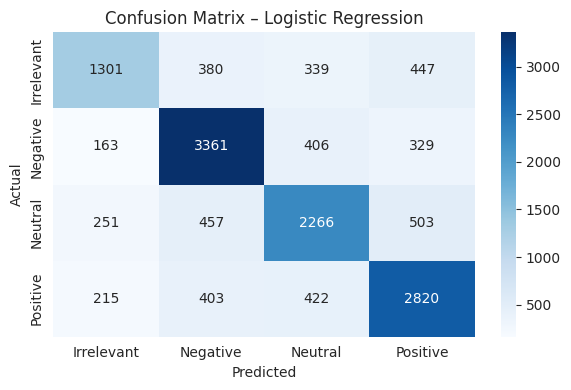

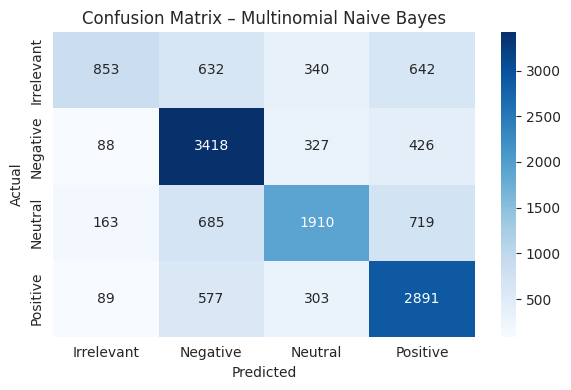

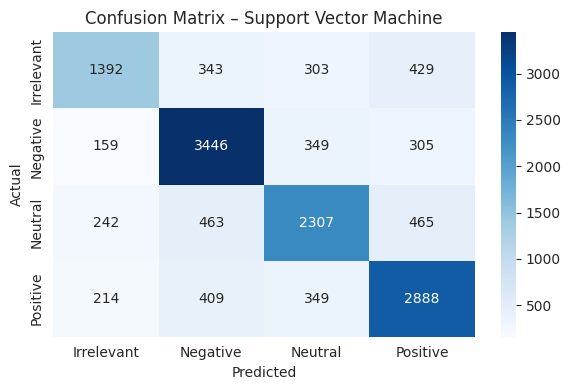

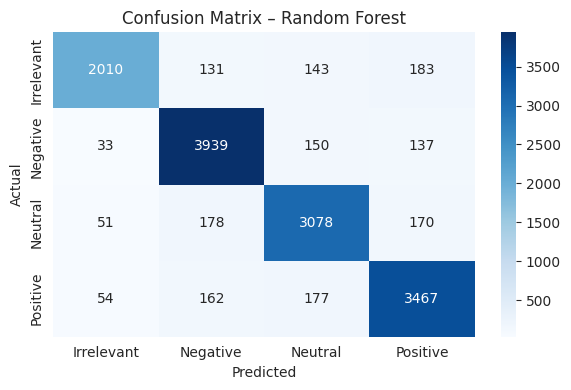

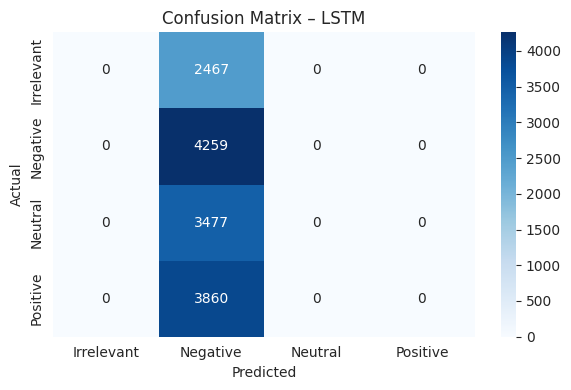

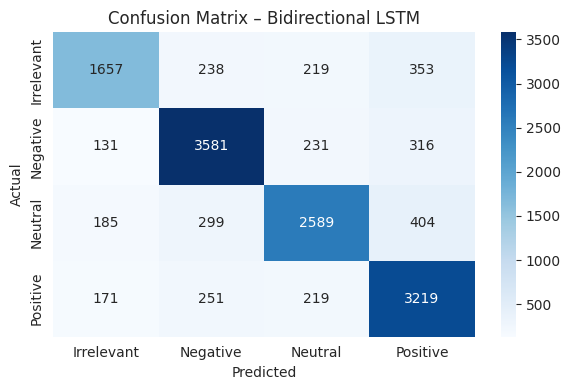

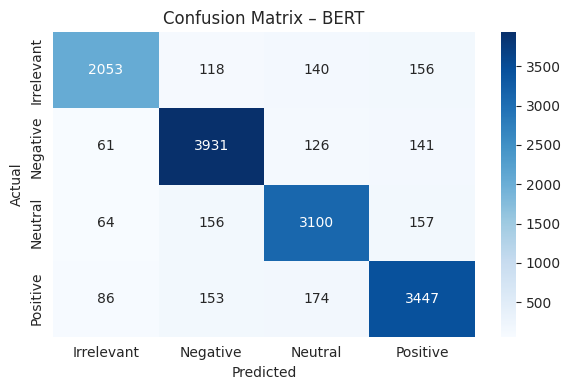

In [80]:
# Confusion matrix heatmap for each model
for name, res in predictions.items():
    cm = confusion_matrix(res['y_true'], res['y_pred'])
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.title(f'Confusion Matrix – {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

## 11. Model Comparison

In [81]:
# Build comparison DataFrame
comparison_df = pd.DataFrame(metrics_summary).T
comparison_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.693166,0.691515,0.693166,0.690244,0.889825
Multinomial Naive Bayes,0.645097,0.653898,0.645097,0.632530,0.870639
Support Vector Machine,0.713432,0.711960,0.713432,0.710786,0.901438
Random Forest,0.888431,0.889643,0.888431,0.888160,0.977476
LSTM,0.302851,0.091719,0.302851,0.140797,0.489264
Bidirectional LSTM,0.785465,0.786141,0.785465,0.784329,0.939976
BERT,0.891062,0.891302,0.891062,0.890840,0.980363


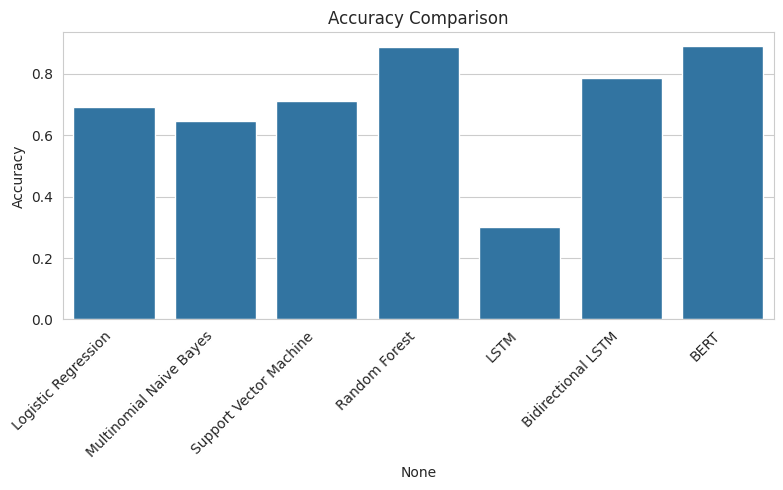

In [82]:
# Bar chart comparing Accuracy across all models
plt.figure(figsize=(8, 5))
sns.barplot(x=comparison_df.index, y=comparison_df['Accuracy'])
plt.xticks(rotation=45, ha='right')
plt.title('Accuracy Comparison')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

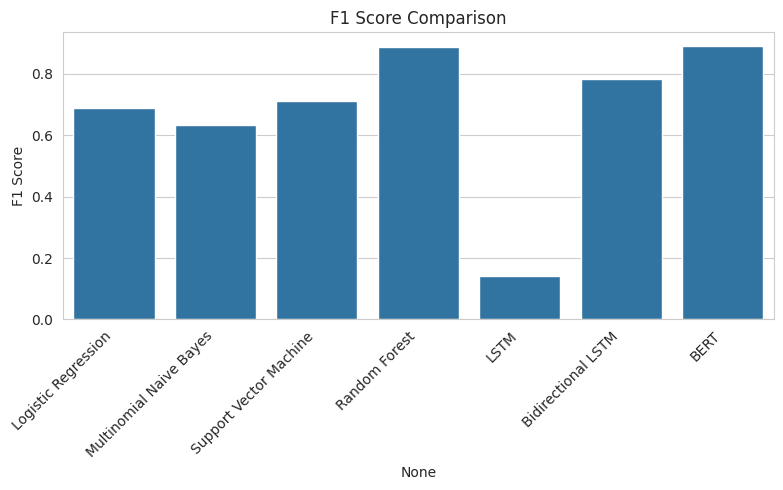

In [83]:
# Bar chart comparing F1 Score across all models
plt.figure(figsize=(8, 5))
sns.barplot(x=comparison_df.index, y=comparison_df['F1 Score'])
plt.xticks(rotation=45, ha='right')
plt.title('F1 Score Comparison')
plt.ylabel('F1 Score')
plt.tight_layout()
plt.show()

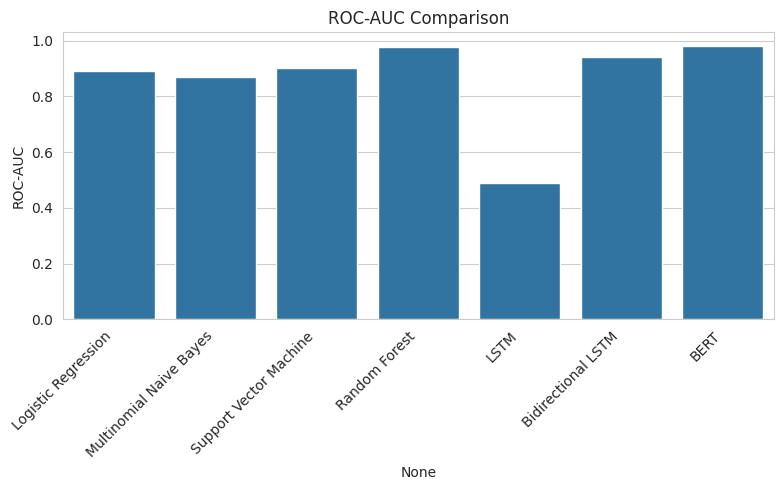

In [84]:
# Bar chart comparing ROC-AUC across all models
plt.figure(figsize=(8, 5))
sns.barplot(x=comparison_df.index, y=comparison_df['ROC-AUC'])
plt.xticks(rotation=45, ha='right')
plt.title('ROC-AUC Comparison')
plt.ylabel('ROC-AUC')
plt.tight_layout()
plt.show()

## 12. Best Model Selection

In [85]:
# Pick the model with the highest weighted F1 Score
best_model_name = comparison_df['F1 Score'].idxmax()
print(f"Best model: {best_model_name}")

Best model: BERT


## 13. Save the Best Model and Vectorizer

In [86]:
# Map model names to their fitted objects
ml_models = {
    'Logistic Regression':      log_reg,
    'Multinomial Naive Bayes':  nb_model,
    'Support Vector Machine':   svm_model,
    'Random Forest':            rf_model
}

dl_models = {
    'LSTM':                bilstm_model,
    'Bidirectional LSTM':  bilstm_model
}

# Save the best model using the appropriate serialisation method
if best_model_name in ml_models:
    # Scikit-learn models → joblib pickle
    joblib.dump(ml_models[best_model_name], 'best_model.pkl')
    joblib.dump(tfidf_vectorizer,           'tfidf_vectorizer.pkl')
    print("Saved ML model and TF-IDF vectorizer.")

elif best_model_name in dl_models:
    # Keras models → HDF5 file
    dl_models[best_model_name].save('best_model.h5')
    with open('tokenizer.pickle', 'wb') as handle:
        pickle.dump(dl_tokenizer, handle)
    print("Saved DL model and tokenizer.")

else:
    # BERT → HuggingFace directory format
    bert_model.save_pretrained('best_bert_model')
    bert_tokenizer.save_pretrained('best_bert_model')
    print("Saved BERT model directory.")

# Always save the label encoder regardless of model type
joblib.dump(label_encoder, 'label_encoder.pkl')
print("Label encoder saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved BERT model directory.
Label encoder saved.


## 14. Predict Sentiment on Custom Text Samples

In [87]:
# Reusable preprocessing pipeline – mirrors the training pipeline exactly
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)                           # remove URLs
    text = re.sub(r'<.*?>', '', text)                                     # remove HTML
    text = re.sub(r'@\w+', '', text)                                      # remove mentions
    text = re.sub(r'#\w+', '', text)                                      # remove hashtags
    text = remove_emojis(text)                                            # remove emojis
    text = re.sub(r'\d+', '', text)                                       # remove digits
    text = text.translate(str.maketrans('', '', string.punctuation))      # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()                             # clean whitespace
    tokens = word_tokenize(text)                                          # tokenise
    tokens = [w for w in tokens if w not in stop_words]                  # stop-word removal
    tokens = [lemmatizer.lemmatize(w) for w in tokens]                   # lemmatise
    return ' '.join(tokens)

In [88]:
# Sample texts to test the saved best model
custom_samples = [
    "I absolutely love the new update, it works perfectly!",
    "This is the worst service I have ever experienced.",
    "The event is scheduled for next Monday at the city hall."
]

# Preprocess each custom sample
processed_samples = [preprocess_text(t) for t in custom_samples]

In [89]:
# Run prediction using the appropriate saved model
if best_model_name in ml_models:
    # ML path – transform with TF-IDF then predict
    sample_vec  = tfidf_vectorizer.transform(processed_samples)
    sample_pred = ml_models[best_model_name].predict(sample_vec)
    sample_labels = label_encoder.inverse_transform(sample_pred)

elif best_model_name in dl_models:
    # DL path – tokenise, pad, then predict with Keras model
    sample_seq  = dl_tokenizer.texts_to_sequences(processed_samples)
    sample_pad  = pad_sequences(sample_seq, maxlen=max_len, padding='post', truncating='post')
    sample_pred = np.argmax(dl_models[best_model_name].predict(sample_pad), axis=1)
    sample_labels = label_encoder.inverse_transform(sample_pred)

else:
    # BERT path – tokenise with BERT tokenizer and run inference
    bert_model.eval()
    device = bert_model.device
    sample_encodings = bert_tokenizer(
        processed_samples, truncation=True, padding=True, max_length=50, return_tensors='pt'
    )
    sample_encodings = {k: v.to(device) for k, v in sample_encodings.items()}
    with torch.no_grad():
        sample_logits = bert_model(**sample_encodings).logits
    sample_pred = np.argmax(
        torch.nn.functional.softmax(sample_logits, dim=1).cpu().numpy(), axis=1
    )
    sample_labels = label_encoder.inverse_transform(sample_pred)

# Print prediction results
print("\n=== Prediction Results ===")
for text, label in zip(custom_samples, sample_labels):
    print(f"  [{label}]  {text}")


=== Prediction Results ===
  [Positive]  I absolutely love the new update, it works perfectly!
  [Negative]  This is the worst service I have ever experienced.
  [Neutral]  The event is scheduled for next Monday at the city hall.


## 15. Streamlit App for Live Sentiment Prediction

### Run Streamlit App in Colab with ngrok


In [90]:
!pip install -q ngrok pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 71.4 MB/s eta 0:00:00


In [95]:
from pyngrok import ngrok

# Using the provided NGROK_AUTH_TOKEN directly
NGROK_AUTH_TOKEN = '3GxJBCdebcGHIdyKGrPRKGgZVFm_25zgcBwKPsWd7HeVMgDwb'
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

print("ngrok authenticated.")

ngrok authenticated.


In [98]:
# Write the Streamlit app to app.py
streamlit_code = '''
import re
import string
import pickle
import joblib
import numpy as np
import streamlit as st

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download NLTK data on first run
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)

# ── Preprocessing helpers ──────────────────────────────────────────────────────
stop_words  = set(stopwords.words("english"))
lemmatizer  = WordNetLemmatizer()

def remove_emojis(text):
    """Strip emoji characters using Unicode ranges."""
    emoji_pattern = re.compile(
        "["
        "\\U0001F600-\\U0001F64F"
        "\\U0001F300-\\U0001F5FF"
        "\\U0001F680-\\U0001F6FF"
        "\\U0001F1E0-\\U0001F1FF"
        "\\U00002700-\\U000027BF"
        "\\U0001F900-\\U0001F9FF"
        "\\U00002600-\\U000026FF"
        "]+",
        flags=re.UNICODE,
    )
    return emoji_pattern.sub("", text)

def preprocess_text(text):
    """Apply the same cleaning pipeline used during training."""
    text = text.lower()
    text = re.sub(r"http\\S+|www\\S+", "", text)                        # URLs
    text = re.sub(r"<.*?>", "", text)                                     # HTML
    text = re.sub(r"@\\w+", "", text)                                     # mentions
    text = re.sub(r"#\\w+", "", text)                                     # hashtags
    text = remove_emojis(text)                                            # emojis
    text = re.sub(r"\\d+", "", text)                                      # digits
    text = text.translate(str.maketrans("", "", string.punctuation))      # punctuation
    text = re.sub(r"\\s+", " ", text).strip()                            # whitespace
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

# ── Load saved model artifacts ─────────────────────────────────────────────────
@st.cache_resource
def load_artifacts():
    """Load model, vectorizer/tokenizer and label encoder from disk."""
    import os, tensorflow as tf

    label_encoder = joblib.load("label_encoder.pkl")

    if os.path.exists("best_model.pkl"):                     # ML model
        model        = joblib.load("best_model.pkl")
        vectorizer   = joblib.load("tfidf_vectorizer.pkl")
        model_type   = "ml"
        tok          = None

    elif os.path.exists("best_model.h5"):                    # Keras DL model
        model        = tf.keras.models.load_model("best_model.h5")
        with open("tokenizer.pickle", "rb") as f:
            tok      = pickle.load(f)
        vectorizer   = None
        model_type   = "dl"

    else:                                                     # BERT model
        from transformers import BertTokenizer, BertForSequenceClassification
        model        = BertForSequenceClassification.from_pretrained("best_bert_model")
        tok          = BertTokenizer.from_pretrained("best_bert_model")
        vectorizer   = None
        model_type   = "bert"

    return model, vectorizer, tok, label_encoder, model_type

model, vectorizer, dl_tok, label_encoder, model_type = load_artifacts()

# ── Prediction function ────────────────────────────────────────────────────────
def predict_sentiment(raw_text):
    """Preprocess text and return predicted sentiment label."""
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    import torch

    cleaned = preprocess_text(raw_text)

    if model_type == "ml":
        vec   = vectorizer.transform([cleaned])
        pred  = model.predict(vec)[0]

    elif model_type == "dl":
        seq   = dl_tok.texts_to_sequences([cleaned])
        pad   = pad_sequences(seq, maxlen=50, padding="post", truncating="post")
        pred  = np.argmax(model.predict(pad), axis=1)[0]

    else:  # BERT
        model.eval()
        enc   = dl_tok([cleaned], truncation=True, padding=True, max_length=50, return_tensors="pt")
        with torch.no_grad():
            logits = model(**enc).logits
        pred  = np.argmax(logits.cpu().numpy(), axis=1)[0]

    return label_encoder.inverse_transform([pred])[0]

# ── Streamlit UI ───────────────────────────────────────────────────────────────
st.set_page_config(page_title="Sentiment Analyser", page_icon="🎭", layout="centered")

st.title("🎭 Sentiment Analyser")
st.write("Enter any text and the model will predict its sentiment.")

# Emoji map for sentiment labels
EMOJI = {"Positive": "😊", "Negative": "😠", "Neutral": "😐", "Irrelevant": "🤷"}

# Single text input
st.subheader("Single Text Prediction")
user_input = st.text_area("Enter text here:", height=120,
                          placeholder="e.g. I love this product!")
if st.button("Predict", type="primary"):
    if user_input.strip():
        label = predict_sentiment(user_input)
        emoji = EMOJI.get(label, "")
        st.success(f"**Predicted Sentiment: {emoji} {label}**")
    else:
        st.warning("Please enter some text.")

# Batch prediction via CSV upload
st.subheader("Batch Prediction (CSV Upload)")
uploaded_file = st.file_uploader("Upload a CSV with a \'text\' column", type="csv")
if uploaded_file:
    import pandas as pd
    batch_df = pd.read_csv(uploaded_file)
    if "text" in batch_df.columns:
        # Predict each row and add results
        batch_df["predicted_sentiment"] = batch_df["text"].astype(str).apply(predict_sentiment)
        st.dataframe(batch_df[["text", "predicted_sentiment"]])
        csv = batch_df.to_csv(index=False).encode("utf-8")
        st.download_button("Download Results", csv, "predictions.csv", "text/csv")
    else:
        st.error("CSV must have a column named \'text\'")

# Footer
st.markdown("---")
st.caption("Comparative Sentiment Analysis Project")
'''

# Write the Streamlit app to disk
with open('app.py', 'w') as f:
    f.write(streamlit_code.strip())

print("app.py written successfully.")
print("Run with:  streamlit run app.py")

app.py written successfully.
Run with:  streamlit run app.py


In [101]:
import os
from pyngrok import ngrok

# 1. Install Streamlit explicitly
!pip install -q streamlit

# 2. Terminate any existing Streamlit/ngrok processes to clear the port
!pkill streamlit
!pkill ngrok

# 3. Re-connect ngrok
try:
    public_url = ngrok.connect(8501)
    print(f'Streamlit App URL: {public_url}')
except Exception as e:
    print(f'Ngrok Error: {e}')

# 4. Run Streamlit and show output logs to debug the 'error'
print("Starting Streamlit... Check the URL above to open the app.")
!streamlit run app.py --server.port 8501

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 73.2 MB/s eta 0:00:00
Streamlit App URL: NgrokTunnel: "https://manhunt-ripeness-cope.ngrok-free.dev" -> "http://localhost:8501"
Starting Streamlit... Check the URL above to open the app.


2026-07-24 15:38:05.146 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.126.71.181:8501

Loading weights: 100% 201/201 [00:00<00:00, 476.97it/s]
  Stopping...
  Stopping...
